In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn


# Dataloader


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),                    # convert image to HxWxC tensors with floats in [0,1]
    transforms.Normalize((0.5,), (0.5,)),     # [-1, 1], cause we do (img - 0.5)/0.5 to get a centered around 0 and unit distribution
])

train_set = datasets.MNIST(
    root="./data",        
    train=True,
    download=True,
    transform=transform,
)

test_set = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.93MB/s]


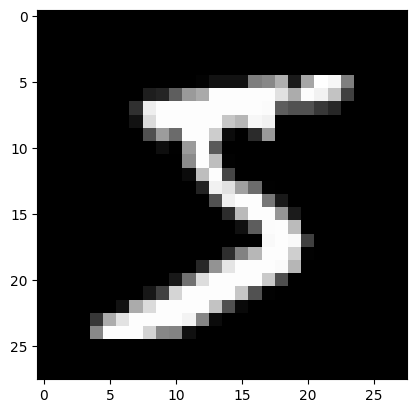

In [3]:
x0, y0 = train_set[0]   # x.shape = 1,28,28
plt.imshow(x0[0,:,:], cmap='grey')

In [4]:
t = torch.tensor([500,0,3])
tp = torch.tensor([500,0,3]).long()
print(t.dtype, tp.dtype)

torch.int64 torch.int64


### LETS DO THE FORWARD PROCESS FIRST

In [59]:
ts=300

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
print(device)

cuda


In [79]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, timesteps=1000, beta_start=3.3e-4, beta_end=0.07):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        betas = torch.linspace(beta_start, beta_end, timesteps)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.)

        self.register_buffer("betas",betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev)
        self.register_buffer("sqrt_alphas_cumprod",  torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod",torch.sqrt(1. - alphas_cumprod))

    
    
    def q_sampling(self, x0, t, noise):
        """ 
        Computing q(x_t | x0) for batch=b
        Cautious with dimensions!:
        x0 : b x C x H x W
        noise : x0 like 
        t : b
        """
        sqrt_alpha_t           = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)           # (B, 1, 1, 1)
        sqrt_one_minus_alpha_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) # like ^

        x_t = sqrt_alpha_t * x0 + sqrt_one_minus_alpha_t * noise
        return x_t
    
    def p_loss(self, x0):
        """
        Compute the loss from x0 -> (B, *)
        """
        B, nts = x0.shape[0], self.timesteps # we need that for the time 
        t = torch.randint(nts, (B,), device=x0.device)
        noise = torch.randn_like(x0)
        x_t = self.q_sampling(x0, t, noise) 
        noise_pred = self.model(x_t, t)       
        loss = ((noise - noise_pred)**2).mean()
        return loss
    
    def p_sampling(self, x, t, eps):
        """
        Computing x_t-1 from eps_theta and x_t
        """
        alpha_t = self.alphas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) #being careful with broadcasting
        beta_t = self.betas[t].view(-1, 1, 1, 1) #being careful with broadcasting
        z = torch.zeros_like(x) if t[0].item() == 0 else torch.randn_like(x)
        x_t_1 = 1/torch.sqrt(alpha_t) * (x - ((1 - alpha_t)/sqrt_one_minus_alpha_bar_t) * eps) + torch.sqrt(beta_t) * z
        return x_t_1

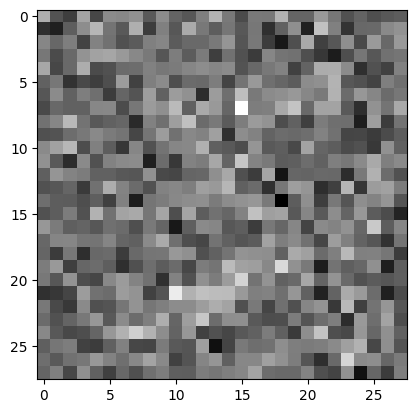

In [80]:
g = GaussianDiffusion(model = None)
noise = torch.randn_like(x0)
t = torch.tensor([200]) 
x_t = g.q_sampling(x0,t, noise)
plt.imshow(x_t[0].squeeze(), cmap="gray")


### Let's do a small MLP first to then test our diffusion model before doing a U-NET

In [81]:
class neuro(nn.Module):
    def __init__(self, dim=28*28, t_dim=128, hidden_dim=512):
        super().__init__()
        self.t_net = nn.Sequential(
            nn.Linear(1, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),nn.SiLU(),
        )

        self.mlp = nn.Sequential(
            nn.Linear(dim + t_dim, hidden_dim//2), nn.SiLU(), # we concat enbedded time and and the vector
            nn.Linear(hidden_dim//2, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, dim), # we get back to our image
        )
    
    def forward(self, x, t):
        """
        x -> (B, C, H, W)
        t -> (B,)
        """
        B, C, H, W = x.shape
        t_emb = self.t_net(((t).float()).unsqueeze(-1)) #unsqueeze cause we're having (B,) for t and we want (B,1) (broadcast)
        x = torch.flatten(x, 1, -1)
        x_concat = torch.cat((x, t_emb), -1)
        out = self.mlp(x_concat)
        return out.view(B,C,H,W)
    


In [82]:
import math
class Sinusembed(nn.Module):
    """
    sinusoidal embedding of time
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        """
        t -> (B,)
        """
        #device = x.device # maybe if I want to train on gpu with bigger models than mnist
        N=10000 #Attention is all you need  N**(k/(dim//2)) 
        h_dim = self.dim//2
        emb = math.log(N)/(h_dim)
        emb = torch.exp(torch.arange(h_dim) * -emb).to(device) # (h_dim,)  # I have to know when to put device or not
        emb = t[:, None] * emb[None,:] #careful with broadcast
        return torch.cat((emb.sin(), emb.cos()), dim=-1)




In [83]:
#test Sinusembed
t = torch.tensor([10,500,300]).to(device)
embed = Sinusembed(16)
t_emb = embed(t)
t_emb.shape

torch.Size([3, 16])

In [ ]:
class RMSnorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim**0.5
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
    def forward(self,x):
        return F.normalize(x, dim=1) * self.g * self.scale #Pytorch formula normalize is the L2 and then we have the



class Resblock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        # self.norm1 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm1 = RMSnorm(out_ch) #we use RMSnorm which is more efficient
        self.act1 = nn.SiLU()
        
        self.time_proj = nn.Sequential(nn.SiLU(),nn.Linear(time_dim, 2 * out_ch)) # we're doing that for the scale and shift instead of just adding the time
        # self.time_proj = nn.Linear(time_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # self.norm2 = nn.GroupNorm(8, out_ch) #batch norm
        self.norm2 = RMSnorm(out_ch)
        self.act2 = nn.SiLU()
        #res_conv = conv1x1 will be useful in upsampling
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity() #we need output and skip(x) to have the same dim
        # self.dropout = nn.Dropout(0.1) # let's see what it does
    def forward(self, x, t_emb):
        #block 1
        t_context = self.time_proj(t_emb) #(B, 2 * out_ch)
        t_context = t_context[:,:,None,None] # We need the time_context to match output (B, 2 * out_ch, 1, 1)
        scale, shift = t_context.chunk(2, dim=1) #tuple (B, out_ch,1,1)

        h1 = self.conv1(x)
        h1 = self.norm1(h1)
        h1 = h1 * (1 + scale) + shift #scale shift DONT FORGET TO TRY WHITHOUT SCALE
        h1 = self.act1(h1)
        #block 2
        # h1 = self.dropout(h1)
        h2 = self.conv2(h1)
        h2 = self.norm2(h2)
        h2 = self.act2(h2)
        return h2 + self.res_conv(x)



In [ ]:
#test for the block (at least shape...)
block = Resblock(in_ch=64, out_ch=128, time_dim=256)
x = torch.randn(4, 64, 14, 14)
t_emb = torch.randn(4, 256)
out = block(x, t_emb)
print(out.shape)

torch.Size([4, 128, 14, 14])


In [ ]:
dim = 5
dim_mults = (1,2,4)
dims = [dim] + [dim * m for m in dim_mults]
in_out = list(zip(dims[:-1], dims[1:]))
in_out_ups = [(b, a) for a, b in reversed(in_out)]
print(in_out, in_out_ups)

[(5, 5), (5, 10), (10, 20)] [(20, 10), (10, 5), (5, 5)]


In [ ]:
def Downsample(dima, dimb):
    return nn.Conv2d(dima, dimb, kernel_size=2, stride=2) # we divide by 2 the image feature resolution
def Upsample(dima, dimb):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="bilinear"), #got helped by google on that one
        nn.Conv2d(dima, dimb, 3, padding=1),
    )
    

class Unet(nn.Module):
    def __init__(self,
                dim,# start dim of embedding in the Unet
                dim_mults=(2, 4),  # lets see
                channel=1  # input channel of our images, mnist is 1
    ):
        super().__init__()
        self.dim = dim
        self.channel = channel
        self.init_conv = nn.Conv2d(channel, dim, kernel_size=3, padding=1) #we keep the same image_size kernel=3 padd=1
        
        #getting the dimensions for ups and downs
        dims = [dim] + [dim * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:])) #giving couple of (in_ch, out_ch)
        
        #timesteps encoder
        time_dim = dim*4 # we make the time embeddign big enough to be approx equal to feature embedding
        self.t_embed = nn.Sequential(Sinusembed(self.dim), nn.Linear(dim, time_dim), nn.GELU(), nn.Linear(time_dim, time_dim))
        #ResBlocks downs
        self.downs = nn.ModuleList([])
        for (in_ch, out_ch) in in_out:
            down = nn.ModuleList([Resblock(in_ch, in_ch, time_dim), Resblock(in_ch, in_ch, time_dim), Downsample(in_ch, out_ch)])
            self.downs.append(down)
        
        #Midblocks
        mid_dim = dims[-1]
        self.mid_block1 = Resblock(mid_dim, mid_dim, time_dim)
        self.mid_block2 = Resblock(mid_dim, mid_dim, time_dim)

        # Resblock up
        self.ups = nn.ModuleList([])
        for (out_ch, in_ch) in reversed(in_out): #careful with the order in_ch, out_ch
            #we multiply by 2, cause we add the vector of the downresblocks as context
            up = nn.ModuleList([Upsample(in_ch, out_ch ),Resblock(2 * out_ch, out_ch, time_dim), Resblock(2 * out_ch, out_ch, time_dim)]) 
            self.ups.append(up)
        
        self.final_conv = nn.Conv2d(dim, channel, 1) #back to channel of the input

    def forward(self, x, t):
        t_emb = self.t_embed(t)
        x = self.init_conv(x)
        
        skips = []
        for down in self.downs:
            res1, res2, dsample = down
            x = res1(x, t_emb)
            skips.append(x)
            x = res2(x, t_emb)
            skips.append(x)
            x = dsample(x)
        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)
        for up in self.ups:
            upsample, res1, res2 = up
            x = upsample(x)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res1(x, t_emb)
            x = torch.cat((x, skips.pop()), dim=1)
            x = res2(x, t_emb)
        x = self.final_conv(x)
        return x


        


In [ ]:
#test Unet
x = torch.randn(4, 1, 28, 28, device=device) #SIZE OF RESOLUTION MUST MATCH THE SIZE IN DIM MULTS
t = torch.tensor([10,500,300,50]).to(device)
unet = Unet(16, (1,2), 1).to(device) #1 = channel of input x 
out = unet(x, t)
print(out.shape, x.shape)

torch.Size([4, 1, 28, 28]) torch.Size([4, 1, 28, 28])


In [ ]:
#test mlp
x = torch.randn((4,1,28,28))
t = torch.randint(0, ts-1, (4,))
net = neuro()
out = net(x,t)
out.shape

torch.Size([4, 1, 28, 28])

/tmp/ipython-input-105-4128143575.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit


epoch 0: loss = 0.489831


/tmp/ipython-input-105-4128143575.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit


epoch 100: loss = 0.057056
epoch 200: loss = 0.018873
epoch 300: loss = 0.013786
epoch 400: loss = 0.043937
epoch 500: loss = 0.038701
epoch 600: loss = 0.025147
epoch 700: loss = 0.019123
epoch 800: loss = 0.023199
epoch 900: loss = 0.017744


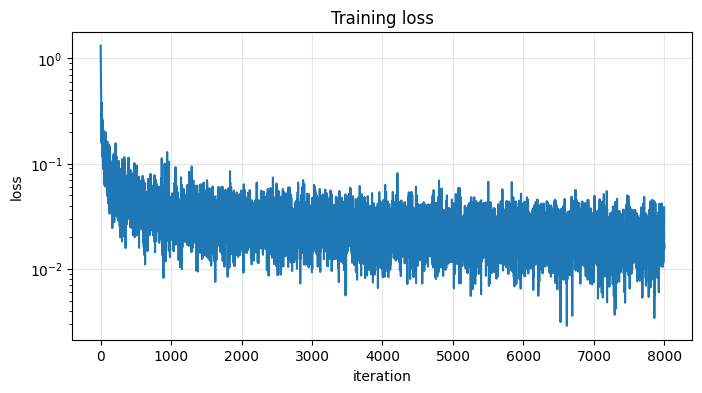

In [ ]:

model = torch.compile(Unet(16, (1,2), 1)).to(device) #before after? speeding

from torch.utils.data import Subset, DataLoader
tiny_set = Subset(train_set, range(128)) #using the whole dataset is useless and too long to train
tiny_loader = DataLoader(tiny_set, batch_size=16, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
diff = GaussianDiffusion(model, timesteps=ts).to(device)
losses = []  

def train_loops(dataloader, diffusion, optimizer):
    diffusion.train()
    scaler = torch.cuda.amp.GradScaler() #add this to speed up a bit
    for _, (X, _) in enumerate(dataloader):
        X = X.to(device)
        with torch.autocast("cuda"):
            loss = diffusion.p_loss(X)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        losses.append(loss.item())


epochs = 1000  # to overfit on 8 images
for epoch in range(epochs):
    train_loops(tiny_loader, diff, optimizer)
    if epoch % 100 == 0:
        print(f"epoch {epoch}: loss = {losses[-1]:.6f}")
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")  
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()



## Groupnorm is really less efficient than RMSnorm (take less time to train), but gives a bit better results since it takes into account the spatial architecture of the features

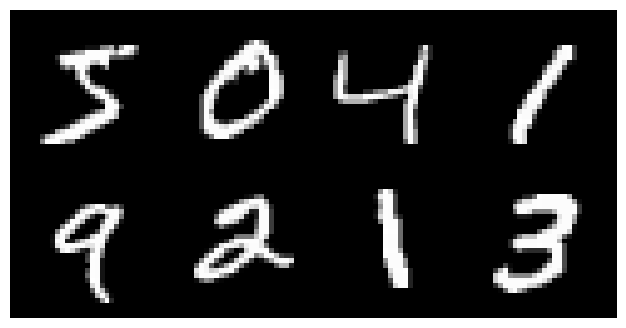

In [ ]:
import torchvision.utils as vutils

imgs = torch.stack([tiny_set[i][0] for i in range(8)])
imgs = (imgs + 1) / 2
grid = vutils.make_grid(imgs, nrow=4)
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.show()

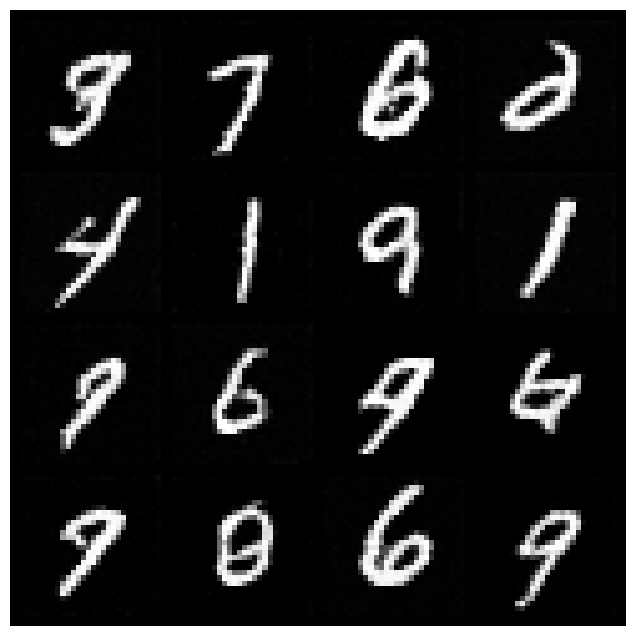

In [ ]:
import torchvision.utils as vutils

n_samples = 16

x_f = torch.randn(n_samples, 1, 28, 28, device=device)
model.eval()
with torch.no_grad():
    for t in range( 299, -1, -1):
        t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device)   
        eps = model(x_f, t_batch)
        x_f = diff.p_sampling(x_f, t_batch, eps)
samples = ((x_f + 1) / 2).clamp(0, 1)


grid = vutils.make_grid(samples.detach().cpu(), nrow=4) #made by claude
plt.figure(figsize=(8, 8))                              #ade by claude
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')  # that too
plt.axis('off')
plt.show()

In [ ]:

from matplotlib import animation
from IPython.display import HTML
#this cell is made by AI
n_samples = 1
save_every = 5  
frames = []

x_f = torch.randn(n_samples, 1, 28, 28, device=device)

model.eval()
with torch.no_grad():
    for t in range(299, -1, -1):
        t_batch = torch.full((n_samples,), t, dtype=torch.long, device=device)
        eps = model(x_f, t_batch)
        x_f = diff.p_sampling(x_f, t_batch, eps)

        if t % save_every == 0:
            grid = vutils.make_grid(
                ((x_f + 1) / 2).clamp(0, 1).detach().cpu(), nrow=4
            )
            frames.append(grid.permute(1, 2, 0).numpy())

# Animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')
im = ax.imshow(frames[0], cmap='gray', animated=True)
title = ax.set_title('')

def update(i):
    im.set_data(frames[i])
    step = 299 - i * save_every
    title.set_text(f't = {step}')
    return im, title

anim = animation.FuncAnimation(
    fig, update, frames=len(frames), interval=100, blit=True
)
plt.close()
HTML(anim.to_jshtml())